In [11]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import os
import numpy as np

In [13]:
csvs = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/min_len_0/paragraph_and_sentence_len_5_min_chunk_len_0_cos_thresh_0.4_nace_level_1_stoxx/*/*.txt_long.csv")
len(csvs)

100

In [14]:
dataset_path = "../data/PDF_stoxx600"
nace_classes = pd.read_excel(os.path.join(dataset_path, "STOXX600_as_of_2025_03_13.xlsx"))
nace_classes

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,Brenntag SE,BNR-DE,BNR-DE,19429.300000,16815.100000,NaN,46.73,G,Brenntag Societas Europaea1.pdf
1,Grafton Group Plc,GFTU-GB,GFTU-GB,2697.420700,2666.632525,NaN,47.52,G,Grafton Group Plc1.pdf
2,LANXESS AG,LXS-DE,LXS-DE,8088.000000,6714.000000,NaN,20.59,C,LANXESS AG1.pdf
3,Banco de Sabadell SA,SAB-ES,SAB-ES,6927.920000,10467.899000,11656.548000,64.19,K,Banco de Sabadell SA1.pdf
4,freenet AG,FNTN-DE,FNTN-DE,2556.714000,2627.300000,NaN,61.20,J,freenet AG1.pdf
...,...,...,...,...,...,...,...,...,...
595,Syensqo SA/NV,SYENS-BE,SYENS-BE,7890.000000,6834.000000,6563.000000,72.11,M,NaN
596,Galderma Group AG,GALD-CH,GALD-CH,3577.917927,3775.451846,4076.950861,21.20,C,NaN
597,"Puig Brands, S.A. Class B",PUIG-ES,PUIG-ES,3619.603000,4304.067000,4789.779000,20.42,C,NaN
598,CVC Capital Partners plc,CVC-NL,CVC-NL,1054.827000,1153.785000,NaN,66.30,K,NaN


In [15]:
dfs = []
for csv in csvs: 
    df = pd.read_csv(csv, index_col=0)
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda row: row.where(row == row.max(), other=pd.NA), axis=1)
    df = pd.melt(df, var_name="NACE_code", value_name="Cos_sim", id_vars=("Sentences"))
    df = df.dropna(subset="Cos_sim")
    
    name = csv.split("/")[-2][:-4] + ".pdf"
    original_code = nace_classes[nace_classes["Report"] == name]["NACE_letter"].iloc[0] 

    df["Original_code"] = original_code
    df["NACE_code_letter"] = df["NACE_code"].apply(lambda x: x.split("_")[1])
    df["Right_classification"] = df["Original_code"] == df["NACE_code_letter"]
    df["Sentence_len"] = df["Sentences"].apply(len)

    dfs.append(df)
full_df = pd.concat(dfs)

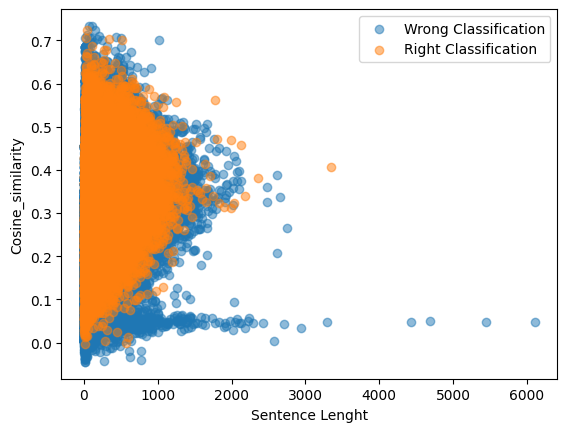

In [16]:
plt.scatter(full_df[~full_df["Right_classification"]]["Sentence_len"], full_df[~full_df["Right_classification"]]["Cos_sim"], alpha = 0.5, label="Wrong Classification")
plt.scatter(full_df[full_df["Right_classification"]]["Sentence_len"], full_df[full_df["Right_classification"]]["Cos_sim"], alpha = 0.5, label="Right Classification")
plt.xlabel("Sentence Lenght")
plt.ylabel("Cosine_similarity")
plt.legend()

For len between 0 and 50:  6614 66059 0.10012261765997063
For len between 10 and 60:  7531 67547 0.11149273838956579
For len between 20 and 70:  7222 57611 0.12535800454774262
For len between 30 and 80:  6360 47346 0.1343302496515017
For len between 40 and 90:  5707 39874 0.14312584641621107
For len between 50 and 100:  5185 35102 0.1477123810609082
For len between 60 and 110:  4825 32119 0.1502226096702886
For len between 70 and 120:  4581 30092 0.15223315166821746
For len between 80 and 130:  4417 28262 0.15628759465006015
For len between 90 and 140:  4276 26870 0.15913658355042798
For len between 100 and 150:  4162 25749 0.16163734513961708
For len between 110 and 160:  4101 24614 0.1666124969529536
For len between 120 and 170:  3948 23412 0.16863147104049206
For len between 130 and 180:  3825 22590 0.1693227091633466
For len between 140 and 190:  3673 21751 0.16886579927359663
For len between 150 and 200:  3511 20846 0.16842559723687997
For len between 160 and 210:  3366 20067 0.16

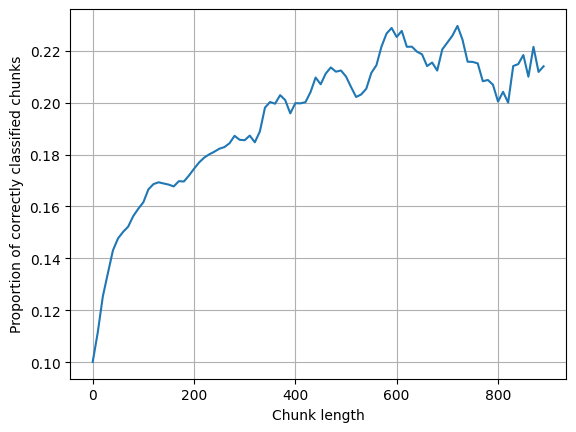

In [19]:
res = []
step = 10
x = list(range(0, 900,step))
for i in x: 
    a = full_df[(full_df["Sentence_len"] > i) & (full_df["Sentence_len"] < i + 50)]
    print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))
    res.append(a["Right_classification"].sum()/ len(a))

plt.plot(x, res)
plt.xlabel("Chunk length")
#plt.ylabel(r"Avg($\sum_i$ max(Cos(Chunk, NACE-Class_i)==NACE-Class_Report))")
plt.ylabel(r"Proportion of correctly classified chunks")
plt.grid()
plt.savefig("../plots/min_chunk_len.pdf")

For len between 0.0 and 50.0:  2 12 0.16666666666666666
For len between 0.01 and 50.01:  0 18 0.0
For len between 0.02 and 50.02:  3 45 0.06666666666666667
For len between 0.03 and 50.03:  1 91 0.01098901098901099
For len between 0.04 and 50.04:  1 141 0.0070921985815602835
For len between 0.05 and 50.05:  1 108 0.009259259259259259
For len between 0.06 and 50.06:  5 84 0.05952380952380952
For len between 0.07 and 50.07:  7 101 0.06930693069306931
For len between 0.08 and 50.08:  10 135 0.07407407407407407
For len between 0.09 and 50.09:  7 140 0.05
For len between 0.1 and 50.1:  12 144 0.08333333333333333
For len between 0.11 and 50.11:  18 180 0.1
For len between 0.12 and 50.12:  19 222 0.08558558558558559
For len between 0.13 and 50.13:  31 268 0.11567164179104478
For len between 0.14 and 50.14:  40 337 0.11869436201780416
For len between 0.15 and 50.15:  52 444 0.11711711711711711
For len between 0.16 and 50.16:  60 550 0.10909090909090909
For len between 0.17 and 50.17:  90 717 0.

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_14070/801974682.py:6: RuntimeWarning: invalid value encountered in scalar divide
  print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))
/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_14070/801974682.py:22: RuntimeWarning: invalid value encountered in scalar divide
  print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))


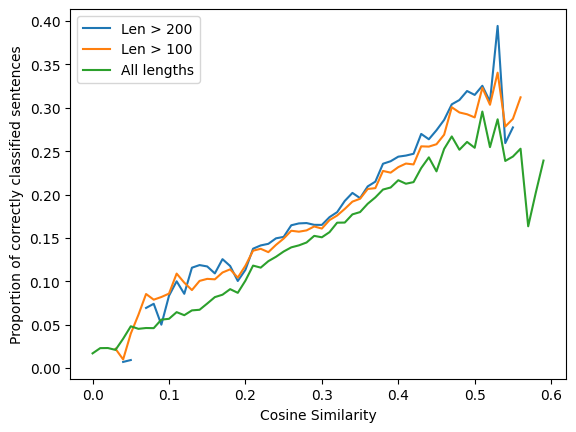

In [8]:
res = []
step = 0.01
x = np.arange(0,1, step)
for i in x: 
    a = full_df[(full_df["Cos_sim"] > i) & (full_df["Cos_sim"] < i + step) & (full_df["Sentence_len"] > 200)]
    print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))
    if len(a) > 100: 
        res.append(a["Right_classification"].sum()/ len(a))
    else: 
        res.append(np.nan)

plt.plot(x, res, label="Len > 200")
plt.xlabel("Cosine Similarity")
#plt.ylabel(r"Avg($\sum_i$ max(Cos(Chunk, NACE-Class_i)==NACE-Class_Report))")
plt.ylabel(r"Proportion of correctly classified sentences")

res = []
step = 0.01
x = np.arange(0,1, step)
for i in x: 
    a = full_df[(full_df["Cos_sim"] > i) & (full_df["Cos_sim"] < i + step) & (full_df["Sentence_len"] > 100)]
    print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))
    if len(a) > 100: 
        res.append(a["Right_classification"].sum()/ len(a))
    else: 
        res.append(np.nan)

plt.plot(x, res, label="Len > 100")
plt.xlabel("Cosine Similarity")
#plt.ylabel(r"Avg($\sum_i$ max(Cos(Chunk, NACE-Class_i)==NACE-Class_Report))")
plt.ylabel(r"Proportion of correctly classified sentences")

res = []
step = 0.01
x = np.arange(0,1, step)
for i in x: 
    a = full_df[(full_df["Cos_sim"] > i) & (full_df["Cos_sim"] < i + step)]
    #print(f"For len between {i} and {i+50}: ", a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a))
    if len(a) > 100: 
        res.append(a["Right_classification"].sum()/ len(a))
    else: 
        res.append(np.nan)

plt.plot(x, res, label="All lengths")
plt.xlabel("Cosine Similarity")
#plt.ylabel(r"Avg($\sum_i$ max(Cos(Chunk, NACE-Class_i)==NACE-Class_Report))")
plt.ylabel(r"Proportion of correctly classified sentences")
plt.legend()

In [ ]:
a = full_df[(full_df["Sentence_len"] > 200) & (full_df["Sentence_len"] < 250)]
a["Right_classification"].sum(), len(a), a["Right_classification"].sum()/ len(a)

(5538, 31437, 0.17616184750453287)

In [173]:
t = full_df[full_df["Cos_sim"]>0.65]
t 

,Sentences,NACE_code,Cos_sim,Original_code,NACE_code_letter,Right_classification,Sentence_len
10369,our network of sewers and pumping stations col...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.677630,E,E,True,272
5426,this included downstream transportation and di...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.664935,A,E,False,468
24612,the funding for financial services activities ...,Scores_K_FINANCIAL AND INSURANCE ACTIVITIES,0.663712,C,K,False,629
43868,the fulfillment of these fields of expertise i...,"Scores_M_PROFESSIONAL, SCIENTIFIC AND TECHNICA...",0.652656,K,M,False,139
13635,wastewater from another organization wastewate...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.668289,M,E,False,123
...,...,...,...,...,...,...,...
11061,waste management services taxonomy activity co...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.700647,I,E,False,121
19966,transportation services taxonomy activities tr...,Scores_H_TRANSPORTATION AND STORAGE,0.689528,I,H,False,150
1153,of operational waste recycled in materials or ...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.676719,L,E,False,53
13081,we manage the waste from our activities includ...,"Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEM...",0.658339,E,E,True,166


# Store to check manually

In [122]:
full_df = full_df[full_df["Sentence_len"] < 150]
full_df = full_df[full_df["Cos_sim"] > 0.4]
full_df = full_df.sort_values("Sentence_len")
full_df["Relevant"] = None
full_df = full_df.drop_duplicates(["Sentences"])

In [93]:
full_df.to_csv("../results/analyze_min_length/analyze_chunk_length.csv")